In [128]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [129]:
# =========================
# MODEL / STRATEGY PARAMETERS
# =========================

PCA_LOOKBACK = 252
N_PCA_FACTORS = 15
OU_WINDOW = 60

ENTRY_THRESHOLD = 2.25
LONG_EXIT_THRESHOLD = 0.25
SHORT_EXIT_THRESHOLD = 0.25

KAPPA_MIN = 8.4

TRANSACTION_COST_BPS = 5
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000

# target gross leverage after stock + factor hedge weights are built
TARGET_GROSS = 2.0

# =========================
# KALMAN PARAMETERS
# =========================

# discount factors (controls how fast model adapts)
DELTA_A = 0.995
DELTA_B = 0.99

# initial state
KF_INIT_A = 0.0
KF_INIT_B = 0.9

# initial uncertainty
KF_INIT_VAR = 0.01

# variance priors
KF_INIT_N = 3.0
KF_INIT_D = 1.0

# safety bounds
B_MIN = 0.0
B_MAX = 0.999

# optional uncertainty filter
USE_UNCERTAINTY_FILTER = False
P_THRESHOLD = 0.05

In [130]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

Number of tickers in universe: 102


$ZI: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found

3 Failed downloads:
['ZI', 'ANSS', 'JNPR']: possibly delisted; no timezone found


In [131]:
# Compute Daily Returns

returns = prices.pct_change(fill_method=None)

In [132]:
# Build Rolling 1 Year windows
valid_dates = returns.index[PCA_LOOKBACK:]
print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2072
Number of valid PCA dates: 1820
First PCA date: 2019-01-03 00:00:00


In [133]:
# Build rolling window index + precompute arrays

window = PCA_LOOKBACK

# integer positions where we can run PCA
valid_pos = np.arange(window, len(returns.index))

# matching dates, just for output / plotting
valid_dates = returns.index[valid_pos]

# precompute once
returns_np = returns.to_numpy()
returns_filled_np = returns.fillna(0.0).to_numpy()
dates_np = returns.index.to_numpy()
col_names = returns.columns.to_numpy()
col_index_map = {col: i for i, col in enumerate(col_names)}

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2072
Number of valid PCA dates: 1820
First PCA date: 2019-01-03 00:00:00


In [147]:
# =========================
# BLOCK 1: RESET + STATE
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# backtest outputs
pnl_series = []
turnover_series = []
active_count_series = []
long_count_series = []
short_count_series = []

# persistent portfolio state
positions = {}
weights_prev = {}

# persistent Kalman state per stock
kf_state = {}
X_history = {}

def init_kf():
    return {
        "m": np.array([KF_INIT_A, KF_INIT_B], dtype=float),
        "P": np.eye(2, dtype=float) * KF_INIT_VAR,
        "n": float(KF_INIT_N),
        "d": float(KF_INIT_D),
        "x_prev": 0.0,
        "var_d": 1e-6   # ← ADD THIS LINE
    }

delta_A = DELTA_A
delta_B = DELTA_B

DEBUG_I = valid_pos[min(300, len(valid_pos) - 1)]

print("State reset complete")
print("-" * 50)
print(f"PCA_LOOKBACK         = {PCA_LOOKBACK}")
print(f"N_PCA_FACTORS        = {N_PCA_FACTORS}")
print(f"OU_WINDOW            = {OU_WINDOW}")
print(f"ENTRY_THRESHOLD      = {ENTRY_THRESHOLD}")
print(f"LONG_EXIT_THRESHOLD  = {LONG_EXIT_THRESHOLD}")
print(f"SHORT_EXIT_THRESHOLD = {SHORT_EXIT_THRESHOLD}")
print(f"KAPPA_MIN            = {KAPPA_MIN}")
print(f"B_MIN, B_MAX         = ({B_MIN}, {B_MAX})")
print(f"USE_UNCERTAINTY_FILTER = {USE_UNCERTAINTY_FILTER}")
print(f"Transaction cost     = {TRANSACTION_COST:.6f}")

print("usable stocks:", len(col_names))
print("valid dates:", len(valid_dates))
print("sample init_kf:", init_kf())

print("=== INIT CHECK ===")
print(f"Initial positions: {len(positions)}")
print(f"Initial KF states: {len(kf_state)}")
print("------------------")



State reset complete
--------------------------------------------------
PCA_LOOKBACK         = 252
N_PCA_FACTORS        = 15
OU_WINDOW            = 60
ENTRY_THRESHOLD      = 2.25
LONG_EXIT_THRESHOLD  = 0.25
SHORT_EXIT_THRESHOLD = 0.25
KAPPA_MIN            = 8.4
B_MIN, B_MAX         = (0.0, 0.999)
USE_UNCERTAINTY_FILTER = False
Transaction cost     = 0.000500
usable stocks: 99
valid dates: 1820
sample init_kf: {'m': array([0. , 0.9]), 'P': array([[0.01, 0.  ],
       [0.  , 0.01]]), 'n': 3.0, 'd': 1.0, 'x_prev': 0.0, 'var_d': 1e-06}
=== INIT CHECK ===
Initial positions: 0
Initial KF states: 0
------------------


Debug date: 2020-03-13 00:00:00
Valid stocks in rolling window: 82
Top 5 explained variance ratios: [0.5144 0.075  0.0264 0.0193 0.0164]
Cumulative explained by 15 factors: 0.7677


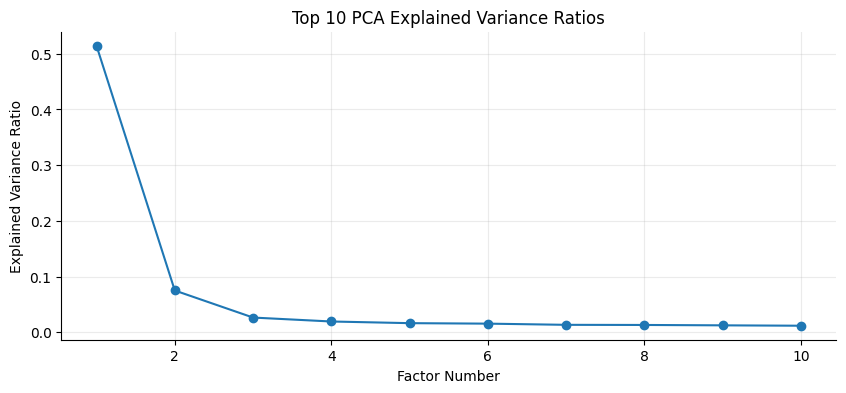

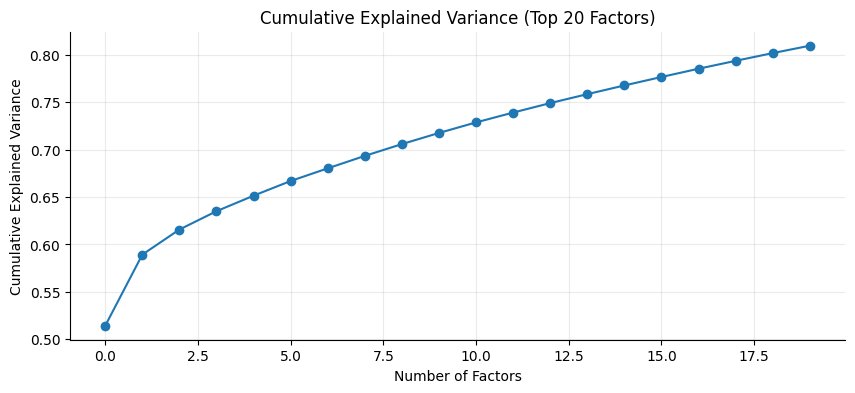


=== PCA DEBUG ===
Date: 2020-03-13 00:00:00


KeyError: 'col_names'

In [149]:
# =========================
# BLOCK 2: SAMPLE PCA SNAPSHOT
# =========================

def build_rolling_snapshot(i):
    window_slice = returns_np[i - PCA_LOOKBACK + 1 : i + 1, :]
    valid_mask = ~np.isnan(window_slice).any(axis=0)

    if valid_mask.sum() < N_PCA_FACTORS + 1:
        return None

    window_data = window_slice[:, valid_mask]
    valid_col_idx = np.where(valid_mask)[0]
    valid_col_names = col_names[valid_col_idx]

    mu = np.mean(window_data, axis=0)
    sigma_raw = np.std(window_data, axis=0, ddof=1)

    sigma_mask = np.isfinite(sigma_raw) & (sigma_raw > 0)
    window_data = window_data[:, sigma_mask]
    sigma = sigma_raw[sigma_mask]
    valid_col_idx = valid_col_idx[sigma_mask]
    valid_col_names = valid_col_names[sigma_mask]

    if window_data.shape[1] < N_PCA_FACTORS + 1:
        return None

    Y = (window_data - mu[sigma_mask]) / sigma
    corr = np.corrcoef(Y, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    V = eigvecs[:, :N_PCA_FACTORS]
    Q_load = V / sigma[:, None]
    F_all = window_data @ Q_load

    reg_window = window_data[-OU_WINDOW:, :]
    F_reg = F_all[-OU_WINDOW:, :]
    X_factor = sm.add_constant(F_reg, has_constant="add")
    factor_today = F_all[-1, :]

    explained = eigvals / eigvals.sum()

    return {
        "i": i,
        "date": returns.index[i],
        "window_data": window_data,
        "valid_col_idx": valid_col_idx,
        "valid_col_names": valid_col_names,
        "sigma": sigma,
        "eigvals": eigvals,
        "explained": explained,
        "Q_load": Q_load,
        "F_all": F_all,
        "reg_window": reg_window,
        "F_reg": F_reg,
        "X_factor": X_factor,
        "factor_today": factor_today
    }

snapshot = build_rolling_snapshot(DEBUG_I)

if snapshot is None:
    print("Snapshot failed: not enough valid names")
else:
    print(f"Debug date: {snapshot['date']}")
    print(f"Valid stocks in rolling window: {len(snapshot['valid_col_names'])}")
    print(f"Top 5 explained variance ratios: {np.round(snapshot['explained'][:5], 4)}")
    print(f"Cumulative explained by {N_PCA_FACTORS} factors: {snapshot['explained'][:N_PCA_FACTORS].sum():.4f}")

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, 11), snapshot["explained"][:10], marker="o")
    plt.title("Top 10 PCA Explained Variance Ratios")
    plt.xlabel("Factor Number")
    plt.ylabel("Explained Variance Ratio")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(np.cumsum(snapshot["explained"][:20]), marker="o")
    plt.title("Cumulative Explained Variance (Top 20 Factors)")
    plt.xlabel("Number of Factors")
    plt.ylabel("Cumulative Explained Variance")
    plt.show()


print("\n=== PCA DEBUG ===")
print(f"Date: {snapshot['date']}")
print(f"# Stocks used: {len(snapshot['col_names'])}")
print(f"Explained variance (top 5): {snapshot['explained_variance'][:5]}")
print(f"Cumulative variance (15 factors): {np.sum(snapshot['explained_variance'][:15]):.3f}")

plt.figure()
plt.plot(np.cumsum(snapshot['explained_variance']), marker='o')
plt.title("Cumulative Explained Variance (PCA)")
plt.xlabel("Number of Factors")
plt.ylabel("Variance Explained")
plt.axhline(0.7, linestyle='--')
plt.show()



Debug stock: ADBE
Residual mean: 0.000000
Residual std : 0.005387
R^2          : 0.9772


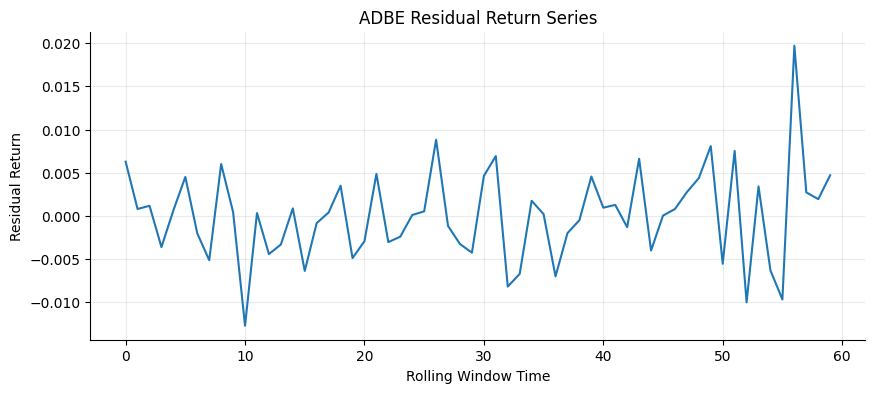

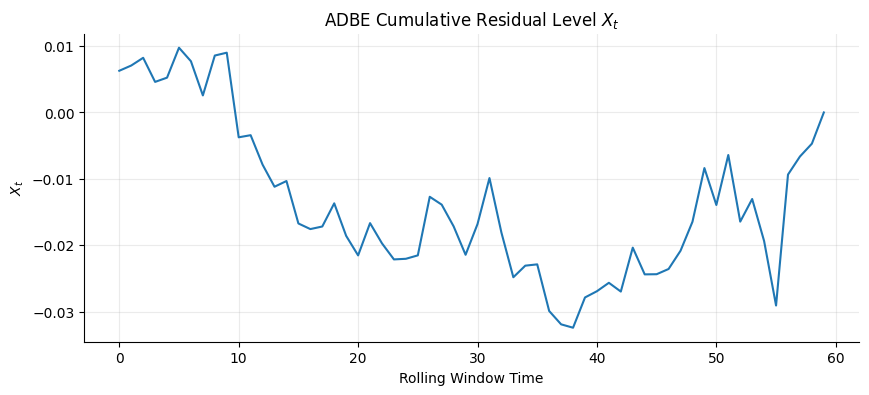

In [136]:
# =========================
# BLOCK 3: SINGLE-STOCK RESIDUAL DIAGNOSTIC
# =========================

if snapshot is None:
    print("Run Block 2 first")
else:
    j_debug = 0
    stock_debug = snapshot["valid_col_names"][j_debug]

    y_hist = snapshot["reg_window"][:, j_debug]
    model_debug = sm.OLS(y_hist, snapshot["X_factor"]).fit()
    resid_debug = model_debug.resid
    x_series_debug = np.cumsum(resid_debug)

    print(f"Debug stock: {stock_debug}")
    print(f"Residual mean: {np.mean(resid_debug):.6f}")
    print(f"Residual std : {np.std(resid_debug):.6f}")
    print(f"R^2          : {model_debug.rsquared:.4f}")

    plt.figure(figsize=(10, 4))
    plt.plot(resid_debug)
    plt.title(f"{stock_debug} Residual Return Series")
    plt.xlabel("Rolling Window Time")
    plt.ylabel("Residual Return")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(x_series_debug)
    plt.title(f"{stock_debug} Cumulative Residual Level $X_t$")
    plt.xlabel("Rolling Window Time")
    plt.ylabel("$X_t$")
    plt.show()

In [137]:
# =========================
# BLOCK 4A: PER-STOCK KALMAN SIGNAL FUNCTION
# =========================

def compute_stock_signal(j, stock, snapshot, kf_state, X_history):
    y_hist = snapshot["reg_window"][:, j]

    # fit stock return on PCA factors WITH intercept
    model = sm.OLS(y_hist, snapshot["X_factor"]).fit()

    alpha = float(model.params[0])
    betas = np.asarray(model.params[1:], dtype=float)

    if stock not in kf_state:
        kf_state[stock] = init_kf()

    if stock not in X_history:
        X_history[stock] = []

    state = kf_state[stock]

    # today's residual update: IMPORTANT -> include intercept
    y_today = float(snapshot["reg_window"][-1, j])
    factor_today = np.asarray(snapshot["factor_today"], dtype=float)
    resid_today = y_today - (alpha + factor_today @ betas)

    x_prev = float(state["x_prev"])
    x_t = x_prev + resid_today
    X_history[stock].append(x_t)

    # previous posterior
    m_prev = np.asarray(state["m"], dtype=float)
    P_prev = np.asarray(state["P"], dtype=float)
    n_prev = float(state["n"])
    d_prev = float(state["d"])

    Phi = np.eye(2)

    W = np.diag([
        ((1.0 - delta_A) / delta_A) * max(P_prev[0, 0], 1e-8),
        ((1.0 - delta_B) / delta_B) * max(P_prev[1, 1], 1e-8)
    ])

    R = Phi @ P_prev @ Phi.T + W

    F_t = np.array([1.0, x_prev], dtype=float)

    a_t = Phi @ m_prev
    one_step_mean = float(F_t @ a_t)
    e_t = x_t - one_step_mean

    S_prev = d_prev / n_prev
    q_t = float(F_t @ R @ F_t.T + 1.0)
    Q_t = S_prev * q_t

    if not np.isfinite(Q_t) or Q_t <= 0:
        return None, betas, None

    K_t = (R @ F_t) / q_t

    m_new = a_t + K_t * e_t
    P_new = R - np.outer(K_t, K_t) * q_t

    if USE_UNCERTAINTY_FILTER and P_new[1, 1] > P_THRESHOLD:
        return None, betas, None

    n_new = n_prev + 1.0
    d_new = d_prev + (S_prev * e_t * e_t) / Q_t

    # save updated Kalman state
    state["m"] = m_new
    state["P"] = P_new
    state["n"] = n_new
    state["d"] = d_new
    state["x_prev"] = x_t

    # dynamic OU parameters
    A_t, B_t = map(float, m_new)
    B_t = min(B_t, B_MAX)

    if not np.isfinite(A_t) or not np.isfinite(B_t):
        return None, betas, None

    if not (B_MIN < B_t < B_MAX):
        return None, betas, None

    kappa = -np.log(B_t) * 252.0
    if not np.isfinite(kappa) or kappa <= KAPPA_MIN:
        return None, betas, None

    mean_denom = 1.0 - B_t
    if mean_denom <= 1e-8:
        return None, betas, None

    m_eq = A_t / mean_denom
    if not np.isfinite(m_eq):
        return None, betas, None

    # =========================
    # NEW: deviation-based sigma
    # =========================

    d_t = x_t - m_eq

    lam = 0.97

    var_d_prev = float(state.get("var_d", 1e-6))
    var_d_new = lam * var_d_prev + (1.0 - lam) * (d_t ** 2)
    state["var_d"] = var_d_new

    sigma_t = np.sqrt(var_d_new)

    if not np.isfinite(sigma_t) or sigma_t <= 1e-12:
        return None, betas, None

    s = d_t / sigma_t

    if not np.isfinite(s):
        return None, betas, None

    if not np.isfinite(s):
        return None, betas, None

    debug = {
        "stock": stock,
        "alpha": alpha,
        "resid_today": resid_today,
        "x_t": x_t,
        "A_t": A_t,
        "B_t": B_t,
        "kappa": kappa,
        "sigma_t": sigma_t,
        "d_t": d_t,
        "m_eq": m_eq,
        "s": s
    }

    return s, betas, debug

print("compute_stock_signal() loaded")

compute_stock_signal() loaded


In [138]:
# =========================
# BLOCK 4B: KALMAN VS SPREAD
# =========================

if len(X_history) == 0:
    print("X_history is empty. Run the backtest loop first.")
else:
    # choose stock with longest history
    stock = max(X_history.keys(), key=lambda k: len(X_history[k]))
    X = np.array(X_history[stock])

    if len(X) < 60:
        print(f"{stock} does not have enough history to plot.")
    else:
        # rebuild a simple visual mean from stored Kalman-like recursion
        state = init_kf()
        x_prev = 0.0
        m_vals = []

        for x_t in X:
            F_t = np.array([1.0, x_prev], dtype=float)
            m_prev = state["m"]
            P_prev = state["P"]

            W = np.diag([
                ((1.0 - delta_A) / delta_A) * max(P_prev[0, 0], 1e-8),
                ((1.0 - delta_B) / delta_B) * max(P_prev[1, 1], 1e-8)
            ])

            R = P_prev + W
            a_t = m_prev
            e_t = x_t - (F_t @ a_t)
            q_t = F_t @ R @ F_t.T + 1.0
            K_t = (R @ F_t) / q_t

            m_new = a_t + K_t * e_t
            P_new = R - np.outer(K_t, K_t) * q_t

            state["m"] = m_new
            state["P"] = P_new

            A_t, B_t = m_new
            B_t = min(B_t, 0.999)

            if (1.0 - B_t) > 1e-8:
                m_eq = A_t / (1.0 - B_t)
            else:
                m_eq = np.nan

            m_vals.append(m_eq)
            x_prev = x_t

        plt.figure(figsize=(12, 5))
        plt.plot(X, label="X_t (Spread)", linewidth=2)
        plt.plot(m_vals, label="Kalman Mean", linewidth=2)
        plt.title(f"Kalman Mean vs Spread: {stock}")
        plt.xlabel("Time")
        plt.ylabel("Level")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"Chosen stock: {stock}")
        print(f"History length: {len(X)}")

X_history is empty. Run the backtest loop first.


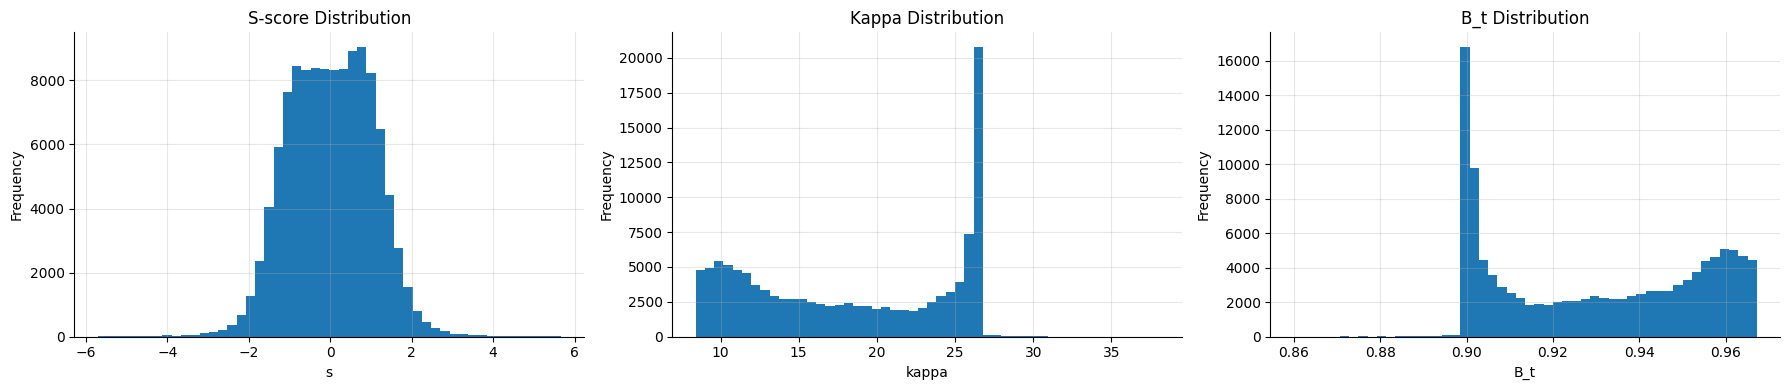

S-score mean: 0.01404577177910963
S-score std : 1.04900165567856
Mean B_t    : 0.9299736634401641
Mean kappa  : 18.37875898673335


In [139]:
# =========================
# BLOCK 4C: SIGNAL DIAGNOSTICS
# =========================

if "debug_df" not in globals() or debug_df.empty:
    print("debug_df is missing or empty. Run the backtest/report block first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(debug_df["s"], bins=50)
    axes[0].set_title("S-score Distribution")
    axes[0].set_xlabel("s")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(debug_df["kappa"], bins=50)
    axes[1].set_title("Kappa Distribution")
    axes[1].set_xlabel("kappa")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    axes[2].hist(debug_df["B_t"], bins=50)
    axes[2].set_title("B_t Distribution")
    axes[2].set_xlabel("B_t")
    axes[2].set_ylabel("Frequency")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    s_vals = debug_df["s"]
    print("S-score mean:", s_vals.mean())
    print("S-score std :", s_vals.std())
    print("Mean B_t    :", debug_df["B_t"].mean())
    print("Mean kappa  :", debug_df["kappa"].mean())

In [140]:
# =========================
# BLOCK 5: POSITION RULES
# =========================

def update_positions(positions, s_values):
    new_positions = positions.copy()

    for stock in list(new_positions.keys()):
        if stock not in s_values:
            new_positions.pop(stock)

    for stock, s in s_values.items():
        pos = new_positions.get(stock, 0)

        if pos == 0:
            if s < -ENTRY_THRESHOLD:
                new_positions[stock] = 1
            elif s > ENTRY_THRESHOLD:
                new_positions[stock] = -1

        elif pos == 1 and s > -LONG_EXIT_THRESHOLD:
            new_positions.pop(stock)

        elif pos == -1 and s < SHORT_EXIT_THRESHOLD:
            new_positions.pop(stock)

    return new_positions

print("update_positions() loaded")

update_positions() loaded


In [141]:
# =========================
# BLOCK 6: PORTFOLIO CONSTRUCTION
# =========================

def build_target_weights(positions, beta_dict):
    longs = [name for name, p in positions.items() if p == 1]
    shorts = [name for name, p in positions.items() if p == -1]

    target_weights = {}
    active_names = longs + shorts
    n_active = len(active_names)

    if n_active > 0:
        w = 1.0 / n_active

        for stock in longs:
            target_weights[stock] = +w

        for stock in shorts:
            target_weights[stock] = -w

        factor_exposure = np.zeros(N_PCA_FACTORS, dtype=float)

        for stock in active_names:
            beta = beta_dict.get(stock)
            if beta is None:
                continue
            factor_exposure += target_weights[stock] * np.asarray(beta, dtype=float)

        for k in range(N_PCA_FACTORS):
            hedge_name = f"FACTOR_{k}"
            target_weights[hedge_name] = -factor_exposure[k]

        # normalize to fixed gross leverage
        gross = sum(abs(wgt) for wgt in target_weights.values())
        if gross > 1e-12:
            scale = TARGET_GROSS / gross
            for name in target_weights:
                target_weights[name] *= scale

    return target_weights, longs, shorts, active_names

print("build_target_weights() loaded")

build_target_weights() loaded


In [142]:
# =========================
# BLOCK 7: ONE-DAY PNL FUNCTION
# =========================

def compute_one_day_pnl(i, snapshot, target_weights):
    if i + 1 >= len(returns_np):
        return None

    next_ret = returns_np[i + 1]
    gross_pnl = 0.0

    valid_idx = snapshot["valid_col_idx"]
    valid_next_ret = next_ret[valid_idx]

    for name, wgt in target_weights.items():

        # single-stock leg
        if name in col_index_map:
            r = next_ret[col_index_map[name]]
            if np.isfinite(r):
                gross_pnl += wgt * r

        # factor hedge leg
        elif name.startswith("FACTOR_"):
            k = int(name.split("_")[1])

            finite_mask = np.isfinite(valid_next_ret)
            if finite_mask.sum() == 0:
                continue

            factor_ret = valid_next_ret[finite_mask] @ snapshot["Q_load"][finite_mask, k]

            if np.isfinite(factor_ret):
                gross_pnl += wgt * factor_ret

    return gross_pnl

print("compute_one_day_pnl() loaded")

compute_one_day_pnl() loaded


In [143]:
# =========================
# BLOCK 8: MAIN BACKTEST LOOP
# =========================

# reset outputs/state before full run
pnl_series = []
turnover_series = []
active_count_series = []
long_count_series = []
short_count_series = []

positions = {}
weights_prev = {}
kf_state = {}
X_history = {}

debug_rows = []

for step_num, i in enumerate(valid_pos):

    snapshot = build_rolling_snapshot(i)

    if snapshot is None:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    s_values = {}
    beta_dict = {}
    local_debug = []

    for j, stock in enumerate(snapshot["valid_col_names"]):
        s, betas, dbg = compute_stock_signal(j, stock, snapshot, kf_state, X_history)

        beta_dict[stock] = betas

        if dbg is not None:
            s_values[stock] = s
            local_debug.append(dbg)

    # empty signal case
    if len(s_values) == 0:
        target_weights = {}

        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        trading_cost = TRANSACTION_COST * turnover

        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)

        positions = {}
        weights_prev = {}
        continue

    positions = update_positions(positions, s_values)
    target_weights, longs, shorts, active_names = build_target_weights(positions, beta_dict)

    long_count_series.append(len(longs))
    short_count_series.append(len(shorts))

    turnover = sum(
        abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
        for n in set(weights_prev) | set(target_weights)
    )

    trading_cost = TRANSACTION_COST * turnover

    gross_pnl = compute_one_day_pnl(i, snapshot, target_weights)

    if gross_pnl is None:
        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(len(active_names))
        break

    net_pnl = gross_pnl - trading_cost

    pnl_series.append(net_pnl)
    turnover_series.append(turnover)
    active_count_series.append(len(active_names))

    weights_prev = target_weights.copy()
    debug_rows.extend(local_debug)

    if step_num % 250 == 0:
        avg_abs_s = np.mean(np.abs(list(s_values.values()))) if len(s_values) > 0 else np.nan
        print(
            f"step={step_num:4d} | date={snapshot['date'].date()} | "
            f"signals={len(s_values):3d} | positions={len(active_names):2d} | "
            f"avg|s|={avg_abs_s:.3f} | turnover={turnover:.4f}"
        )

print("Backtest loop finished")
print(f"Stored Kalman states: {len(kf_state)}")
print(f"Stocks with X-history: {len(X_history)}")

step=   0 | date=2019-01-03 | signals= 78 | positions=60 | avg|s|=3.700 | turnover=2.0000
step= 250 | date=2019-12-31 | signals= 82 | positions=13 | avg|s|=0.831 | turnover=0.0398
step= 500 | date=2020-12-28 | signals= 86 | positions=10 | avg|s|=0.800 | turnover=0.0048
step= 750 | date=2021-12-23 | signals= 69 | positions=11 | avg|s|=0.765 | turnover=0.6675
step=1000 | date=2022-12-21 | signals= 62 | positions= 9 | avg|s|=0.891 | turnover=0.0017
step=1250 | date=2023-12-20 | signals= 47 | positions= 2 | avg|s|=0.728 | turnover=1.9902
step=1500 | date=2024-12-18 | signals= 36 | positions= 9 | avg|s|=0.805 | turnover=0.4654
step=1750 | date=2025-12-18 | signals= 54 | positions= 4 | avg|s|=0.802 | turnover=0.0411
Backtest loop finished
Stored Kalman states: 99
Stocks with X-history: 99



========== MODEL REPORT ==========

---- PERFORMANCE ----
Annual Return     : -0.0551
Annual Vol        : 0.2570
Sharpe Ratio      : -0.2144
Max Drawdown      : -0.6276
Calmar Ratio      : -0.0878

---- TRADE QUALITY ----
Win Rate          : 0.5071
Avg Win           : 0.01075
Avg Loss          : -0.01151
Profit Factor     : 0.9615

---- POSITION STATS ----
Avg Longs         : 5.15
Avg Shorts        : 5.65
Avg Positions     : 10.80
Long/Short Ratio  : 0.91
% Days Active     : 1.00

---- ACTIVITY ----
Avg Turnover      : 0.3053
% Trading Days    : 1.00

---- SIGNAL DIAGNOSTICS ----
               B_t        kappa          d_t      sigma_t            s
count  116851.0000  116851.0000  116851.0000  116851.0000  116851.0000
mean        0.9300      18.3787       0.0002       0.0378       0.0141
std         0.0240       6.4986       0.0478       0.0285       1.0490
min         0.8599       8.4002      -0.4322       0.0010      -5.7178
25%         0.9037      11.9094      -0.0208       0.0184

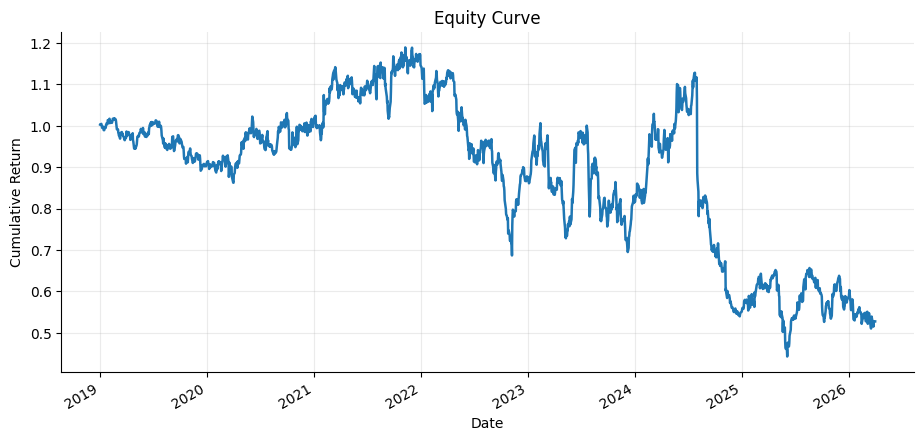

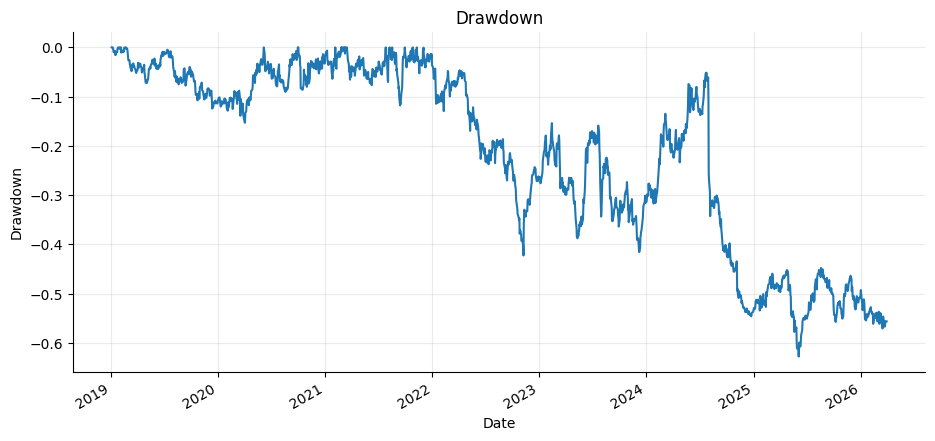

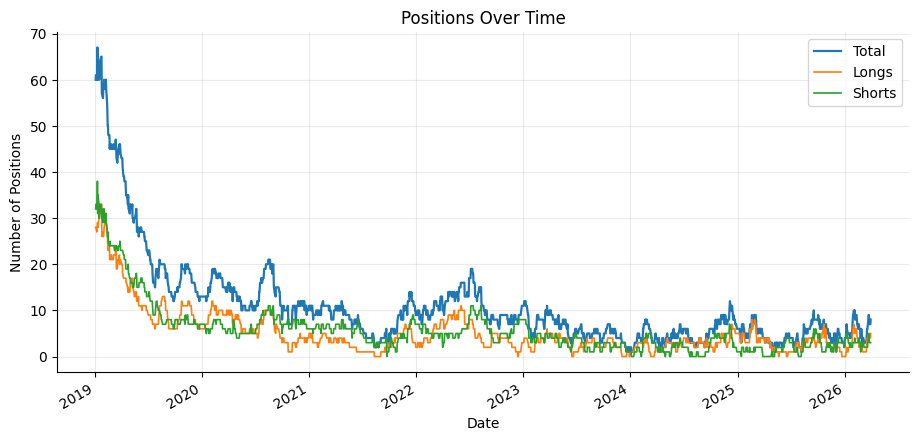

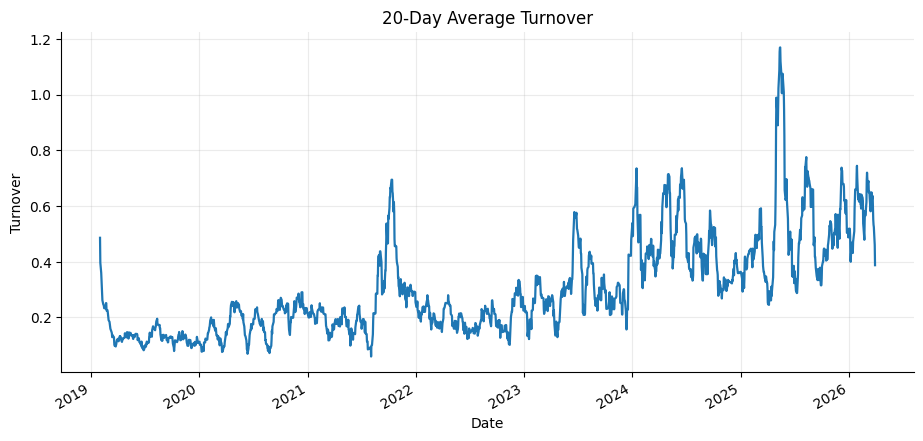

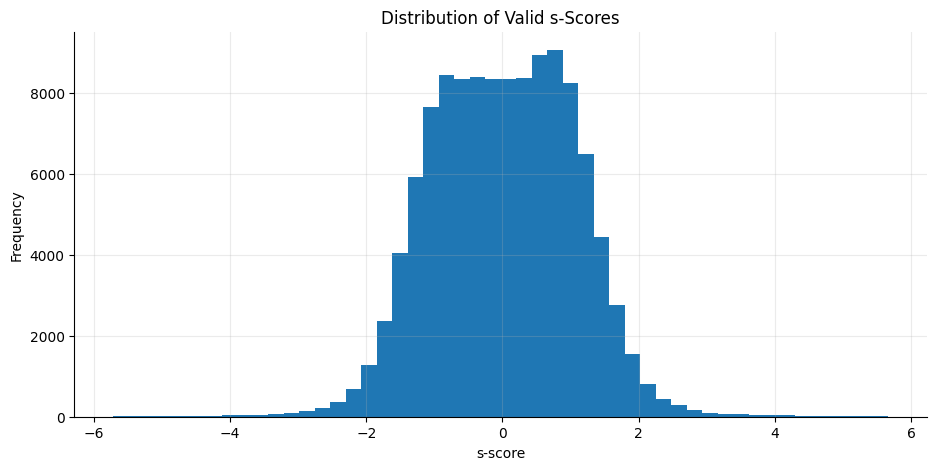

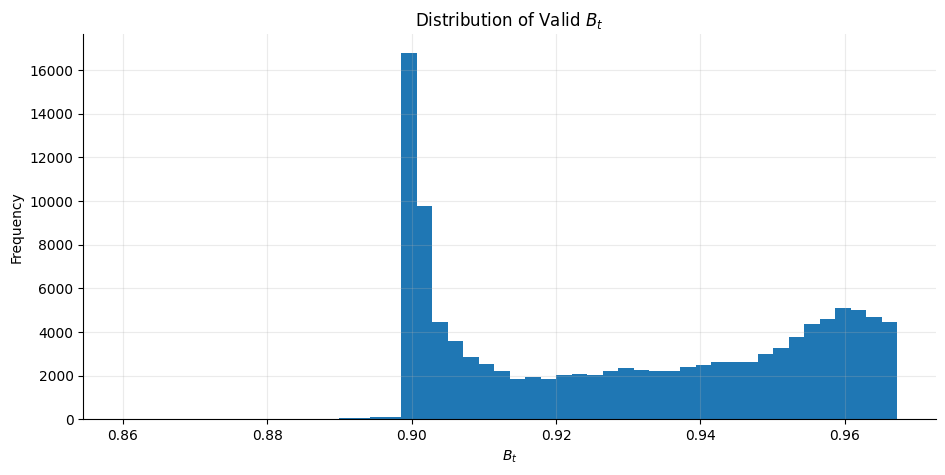

In [144]:
# =========================
# BLOCK 9: OUTPUTS + DIAGNOSTICS
# =========================

out_dates = valid_dates[:len(pnl_series)]

pnl_series = pd.Series(pnl_series, index=out_dates)
turnover_series = pd.Series(turnover_series, index=out_dates)
active_count_series = pd.Series(active_count_series, index=out_dates)
long_count_series = pd.Series(long_count_series, index=out_dates)
short_count_series = pd.Series(short_count_series, index=out_dates)

ret = pnl_series.copy()

mean_daily = ret.mean()
std_daily = ret.std()

ann_factor = 252
mean_annual = mean_daily * ann_factor
vol_annual = std_daily * np.sqrt(ann_factor)
sharpe = mean_annual / vol_annual if vol_annual > 0 else np.nan

cum_returns = (1 + ret).cumprod()
running_max = cum_returns.cummax()
drawdown = cum_returns / running_max - 1
max_dd = drawdown.min()
calmar = mean_annual / abs(max_dd) if max_dd != 0 else np.nan

win_rate = (ret > 0).mean()
avg_win = ret[ret > 0].mean()
avg_loss = ret[ret < 0].mean()

gross_profit = ret[ret > 0].sum()
gross_loss = ret[ret < 0].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan

avg_longs = long_count_series.mean()
avg_shorts = short_count_series.mean()
avg_positions = active_count_series.mean()
long_short_ratio = avg_longs / avg_shorts if avg_shorts > 0 else np.nan
pct_days_active = (active_count_series > 0).mean()

avg_turnover = turnover_series.mean()
pct_trading_days = (turnover_series > 0).mean()

print("\n========== MODEL REPORT ==========\n")
print("---- PERFORMANCE ----")
print(f"Annual Return     : {mean_annual:.4f}")
print(f"Annual Vol        : {vol_annual:.4f}")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Max Drawdown      : {max_dd:.4f}")
print(f"Calmar Ratio      : {calmar:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {win_rate:.4f}")
print(f"Avg Win           : {avg_win:.5f}")
print(f"Avg Loss          : {avg_loss:.5f}")
print(f"Profit Factor     : {profit_factor:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {avg_longs:.2f}")
print(f"Avg Shorts        : {avg_shorts:.2f}")
print(f"Avg Positions     : {avg_positions:.2f}")
print(f"Long/Short Ratio  : {long_short_ratio:.2f}")
print(f"% Days Active     : {pct_days_active:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {avg_turnover:.4f}")
print(f"% Trading Days    : {pct_trading_days:.2f}")

debug_df = pd.DataFrame(debug_rows)
if len(debug_df) > 0:
    print("\n---- SIGNAL DIAGNOSTICS ----")
    print(debug_df[["B_t", "kappa", "d_t", "sigma_t", "s"]].describe().round(4))

# Pretty plots
plt.figure(figsize=(11, 5))
cum_returns.plot(linewidth=1.8)
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

plt.figure(figsize=(11, 5))
drawdown.plot(linewidth=1.5)
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

plt.figure(figsize=(11, 5))
active_count_series.plot(label="Total", linewidth=1.6)
long_count_series.plot(label="Longs", linewidth=1.2)
short_count_series.plot(label="Shorts", linewidth=1.2)
plt.title("Positions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Positions")
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
turnover_series.rolling(20).mean().plot(linewidth=1.6)
plt.title("20-Day Average Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.show()

if len(debug_df) > 0:
    plt.figure(figsize=(11, 5))
    plt.hist(debug_df["s"], bins=50)
    plt.title("Distribution of Valid s-Scores")
    plt.xlabel("s-score")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.hist(debug_df["B_t"], bins=50)
    plt.title("Distribution of Valid $B_t$")
    plt.xlabel("$B_t$")
    plt.ylabel("Frequency")
    plt.show()